# Objectif du notebook 02_data_visualization.ipynb
Visualiser la qualité, la structure et la distribution des données
AVANT toute opération de nettoyage ou de modélisation.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))
#print(PROJECT_ROOT)
#print(sys.path.insert(0, str(PROJECT_ROOT)))

In [3]:
from src.config.spark_session import get_spark_session

spark = get_spark_session()


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/23 14:12:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/12/23 14:12:52 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [9]:
from pyspark.sql.functions import col, isnan, count, when
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [5]:
data_path = "/Users/yassineoc/Desktop/hamza/Projet_Spark/Customer Segmentation and Churn Prediction with PySpark/data/raw/Online Retail.csv"

df = spark.read.csv(
    data_path,
    header=True,
    inferSchema=True
)

In [6]:
n_rows = df.count()
n_cols = len(df.columns)

print(f"Nombre de lignes : {n_rows}")
print(f"Nombre de colonnes : {n_cols}")


Nombre de lignes : 541909
Nombre de colonnes : 8


      Variable    Type
0    InvoiceNo  string
1    StockCode  string
2  Description  string
3     Quantity     int
4  InvoiceDate  string
5    UnitPrice  double
6   CustomerID     int
7      Country  string


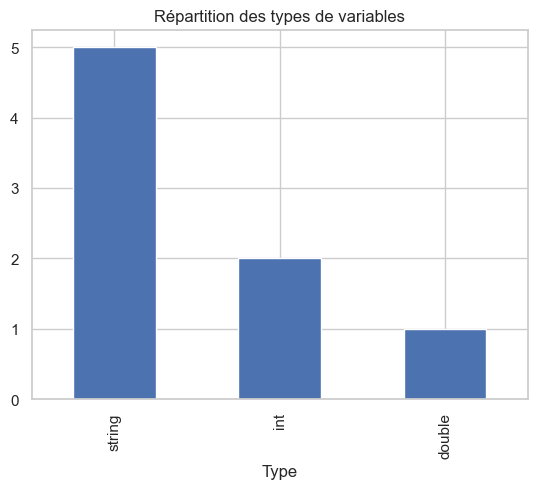

In [7]:
schema_df = pd.DataFrame(
    [(field.name, field.dataType.simpleString()) for field in df.schema.fields],
    columns=["Variable", "Type"]
)

print(schema_df)

schema_df["Type"].value_counts().plot(kind="bar")
plt.title("Répartition des types de variables")
plt.show()



In [10]:
#Analyse des valeurs manquantes
missing_df = df.select([
    count(
        when(col(c).isNull() | isnan(col(c)), c)
    ).alias(c)
    for c in df.columns
])

missing_pd = missing_df.toPandas().T
missing_pd.columns = ["Missing_Count"]
missing_pd["Missing_%"] = (missing_pd["Missing_Count"] / n_rows) * 100
missing_pd.sort_values("Missing_%", ascending=False).head(10)


,Missing_Count,Missing_%
CustomerID,135080,24.926694
Description,1454,0.268311
StockCode,0,0.000000
InvoiceNo,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
Country,0,0.000000


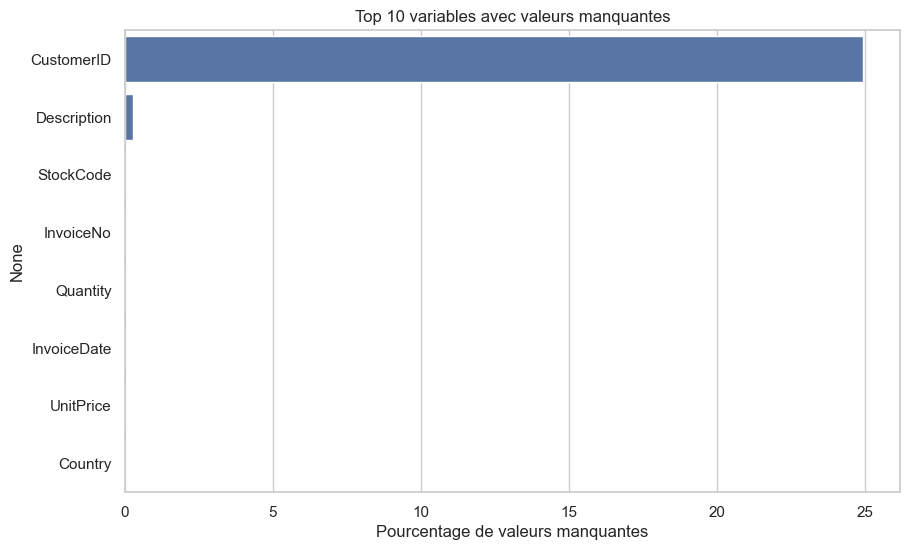

In [11]:
# Visualisation des valeurs manquantes

plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_pd["Missing_%"].sort_values(ascending=False).head(10),
    y=missing_pd.sort_values("Missing_%", ascending=False).head(10).index
)
plt.title("Top 10 variables avec valeurs manquantes")
plt.xlabel("Pourcentage de valeurs manquantes")
plt.show()


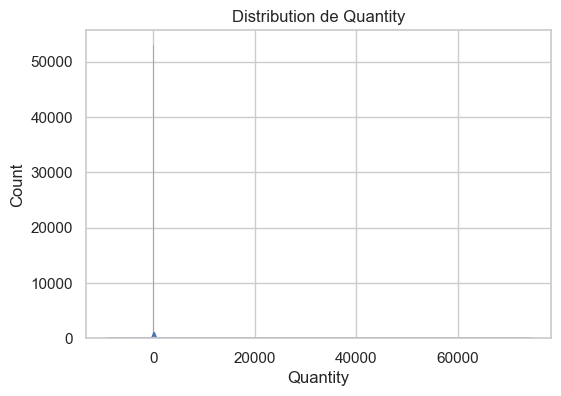

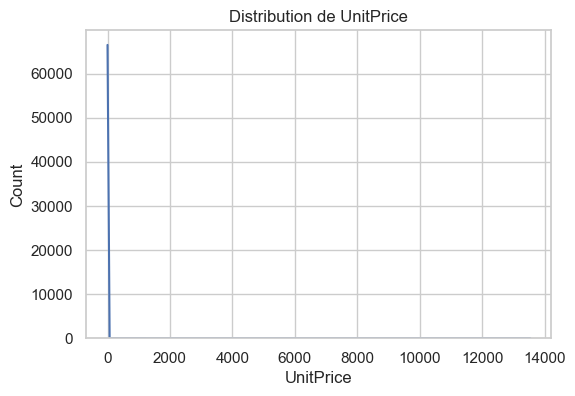

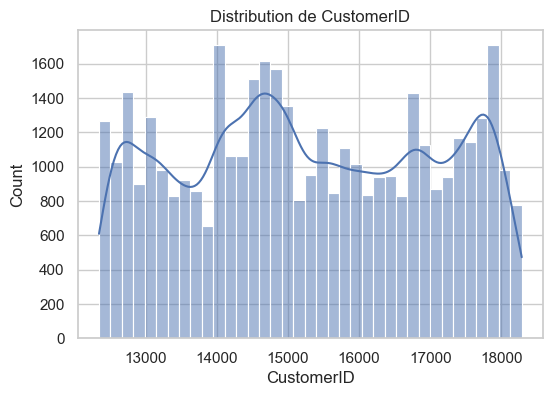

In [12]:
#Échantillonnage contrôlé pour Pandas

sample_df = df.sample(fraction=0.1, seed=42).toPandas()
#Distribution des variables numériques
numeric_cols = sample_df.select_dtypes(include=np.number).columns

for col_name in numeric_cols[:5]:
    plt.figure(figsize=(6, 4))
    sns.histplot(sample_df[col_name], kde=True)
    plt.title(f"Distribution de {col_name}")
    plt.show()


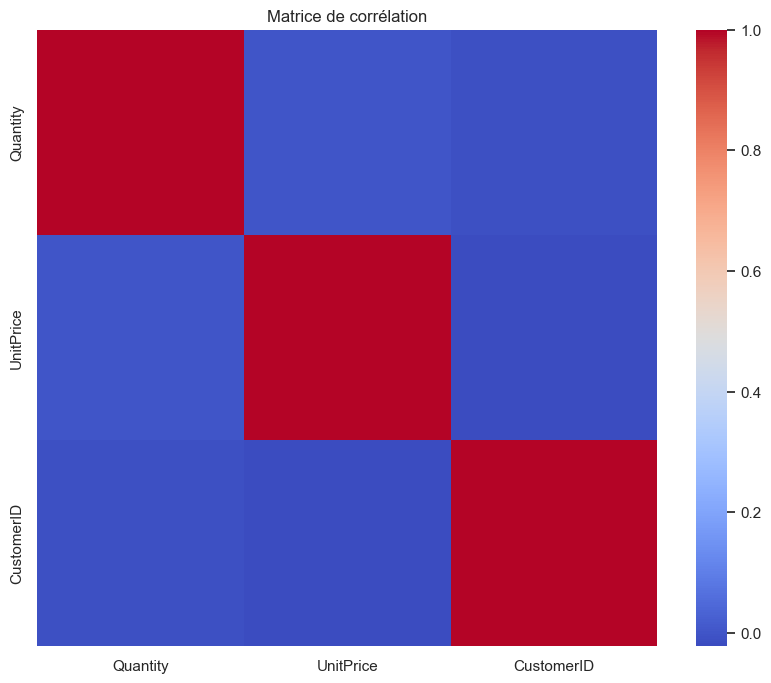

In [13]:
# Matrice de correlation

plt.figure(figsize=(10, 8))
sns.heatmap(sample_df[numeric_cols].corr(), cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()
